# O Coração das Empresas: **Clientes**
### Análise de Satisfação — Olist E-commerce Dataset
> Análise Descritiva · Diagnóstica · Preditiva

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Paleta de cores consistente
COLOR_MAIN       = '#2E86AB'
COLOR_OK         = '#0a5c0a'
COLOR_OK_DARK    = '#228b22'
COLOR_WARN       = '#F6AE2D'
COLOR_BAD        = '#E84855'
COLOR_BAD_DARK   = '#660000'
PALETTE_SCORE = [COLOR_BAD_DARK, COLOR_BAD, COLOR_WARN, COLOR_OK, COLOR_OK_DARK]

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})

## 1. Carregamento e Merge dos Dados

Entendendo quantos dos nossos pedidos tem review

In [ ]:
df_customers     = pd.read_csv('/content/olist_customers_dataset.csv')
df_orders        = pd.read_csv('/content/olist_orders_dataset.csv')
df_order_items   = pd.read_csv('/content/olist_order_items_dataset.csv')
df_order_payments= pd.read_csv('/content/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')

# Converter timestamps
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

# Calcular lead times
df_orders['lead_time_days'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_orders['delay_days'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']
).dt.days

df_orders['is_late'] = df_orders['delay_days'] > 0

# Merge principal
df = (df_orders
      .merge(df_order_reviews[['order_id','review_score']], on='order_id', how='left')
      .merge(df_customers[['customer_id','customer_state']], on='customer_id', how='left')
      .merge(df_order_items.groupby('order_id').agg(
                 price=('price','sum'),
                 freight_value=('freight_value','sum')
             ).reset_index(), on='order_id', how='left')
      .merge(df_order_payments.groupby('order_id').agg(
                 payment_type=('payment_type','first'),
                 installments=('payment_installments','mean')
             ).reset_index(), on='order_id', how='left')
     )

df_delivered = df[df['order_status'] == 'delivered'].dropna(subset=['review_score','lead_time_days'])
print(f'Pedidos entregues com review: {len(df_delivered):,}')

Pedidos entregues com review: 96,353


---
## 2. Análise Descritiva
> Medidas de tendência central e variabilidade do review_score

In [ ]:
score = df_delivered['review_score']

desc = {
    'Média':          round(score.mean(), 2),
    'Desvio Padrão':  round(score.std(), 2),
    'Variância':      round(score.var(), 2),
    'CV (%)':         round((score.std() / score.mean()) * 100, 1),
    'Mínimo':         int(score.min()),
    'Máximo':         int(score.max()),
}

df_desc = pd.DataFrame(desc.items(), columns=['Métrica', 'Valor'])
print(df_desc.to_string(index=False))

cv = desc['CV (%)']
nivel = 'BAIXO (< 15%)' if cv < 15 else ('ALTO (> 30%)' if cv > 30 else 'MÉDIO (15–30%)')
print(f'\nCoeficiente de Variação: {cv}% → Variabilidade {nivel}')

      Métrica  Valor
        Média   4.16
Desvio Padrão   1.28
    Variância   1.65
       CV (%)  30.90
       Mínimo   1.00
       Máximo   5.00

Coeficiente de Variação: 30.9% → Variabilidade ALTO (> 30%)


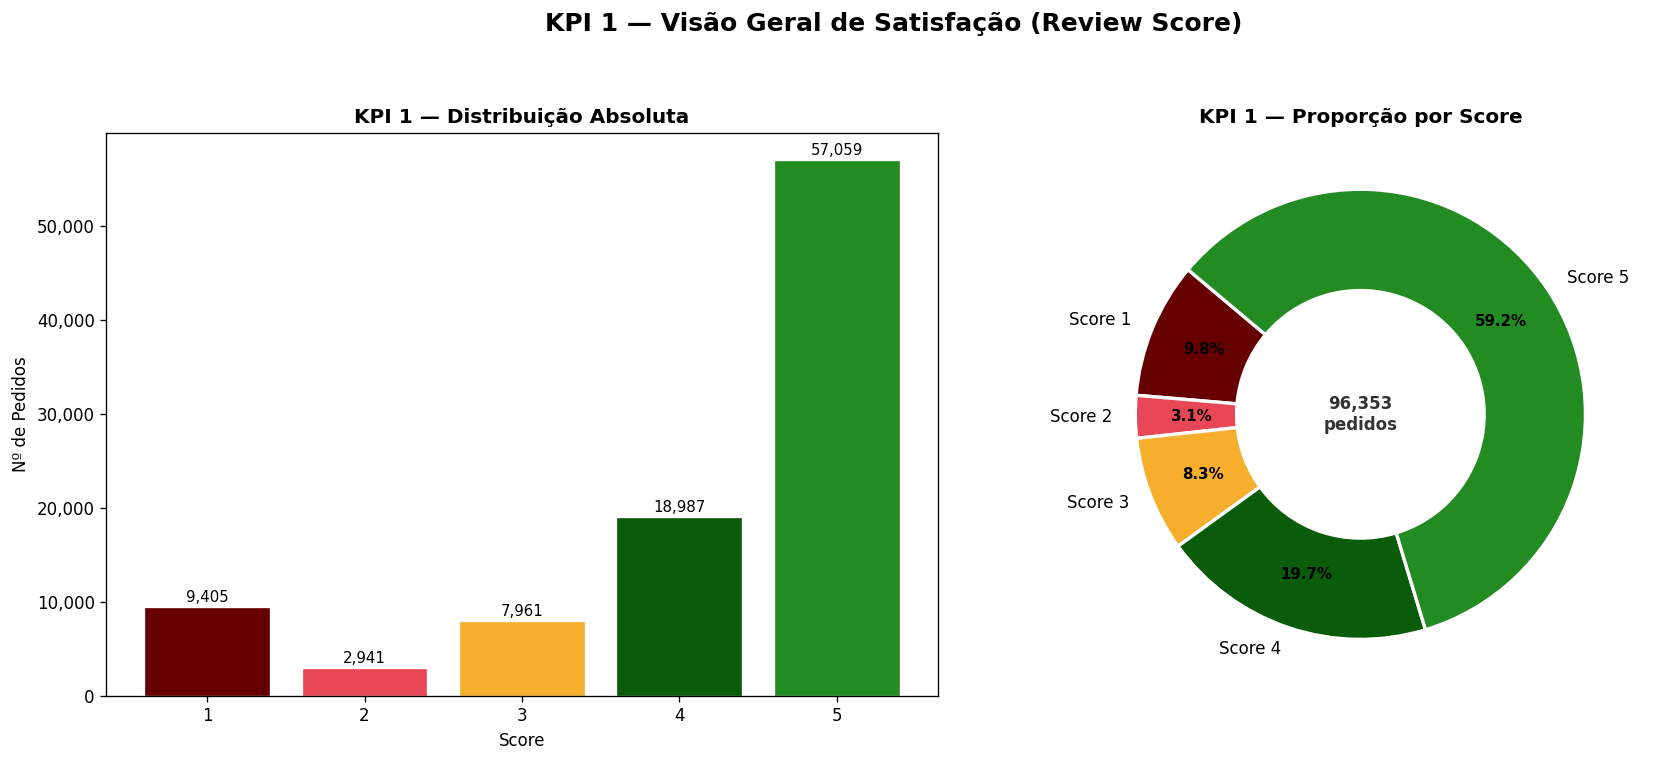

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de Barras (Distribuição Absoluta)
counts = df_delivered['review_score'].value_counts().sort_index()
bars = ax1.bar(counts.index, counts.values, color=PALETTE_SCORE, edgecolor='white', linewidth=0.8)
ax1.set_title('KPI 1 — Distribuição Absoluta', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score')
ax1.set_ylabel('Nº de Pedidos')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

# 2. Gráfico de Donut (Proporção Relativa)
labels_map = {1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4', 5:'Score 5'}
labels = [labels_map[i] for i in counts.index]

wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    colors=PALETTE_SCORE,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax2.text(0, 0, f'{counts.sum():,}\npedidos', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#333333')

ax2.set_title('KPI 1 — Proporção por Score', fontsize=12, fontweight='bold')

plt.suptitle('KPI 1 — Visão Geral de Satisfação (Review Score)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 3. Análise Diagnóstica
> Por que os clientes ficam insatisfeitos?

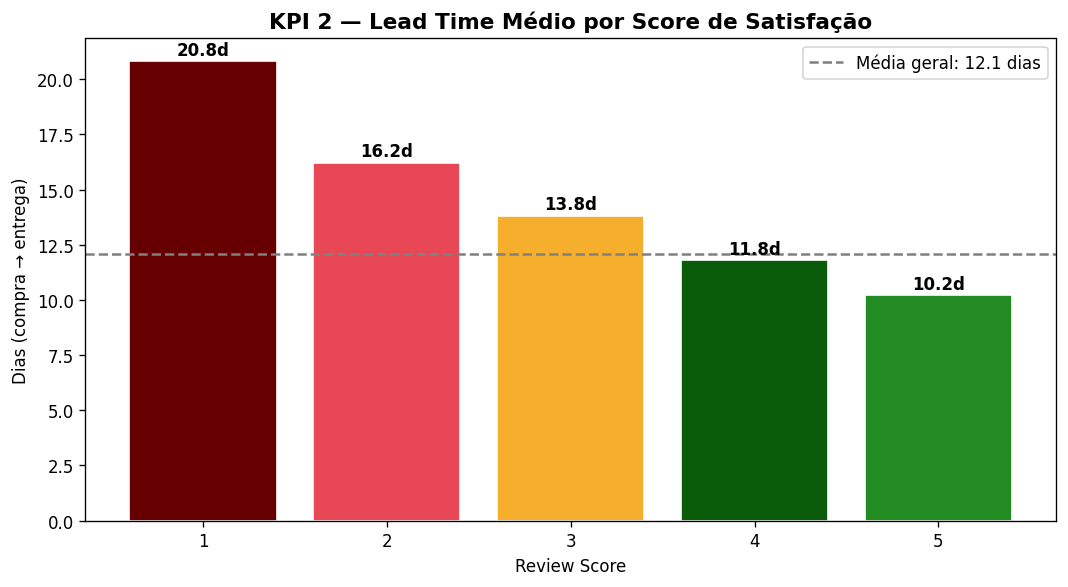

In [ ]:
# KPI 2 — Lead time médio por score
lead_by_score = df_delivered.groupby('review_score')['lead_time_days'].mean().round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(lead_by_score.index, lead_by_score.values, color=PALETTE_SCORE, edgecolor='white')
ax.set_title('KPI 2 — Lead Time Médio por Score de Satisfação', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Dias (compra → entrega)')
media_geral = df_delivered['lead_time_days'].mean()
ax.axhline(media_geral, color='gray', linestyle='--', label=f'Média geral: {media_geral:.1f} dias')
ax.legend()
for bar, val in zip(bars, lead_by_score.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}d', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

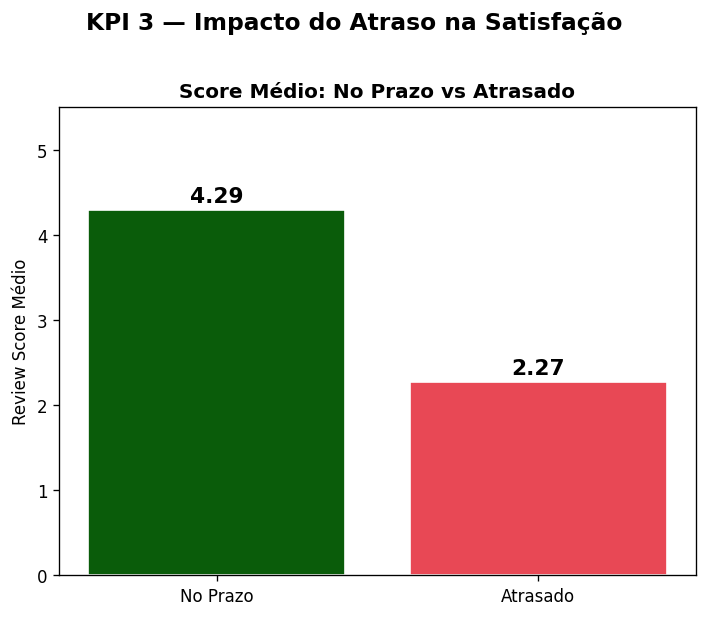

In [ ]:
# KPI 3 — Taxa de atraso e impacto no score
atraso_score = df_delivered.groupby('is_late')['review_score'].mean().round(2)
taxa_atraso  = df_delivered['is_late'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))

cores_atraso = [COLOR_OK, COLOR_BAD]
labels_atraso = ['No Prazo', 'Atrasado']
ax.bar(labels_atraso, atraso_score.values, color=cores_atraso, edgecolor='white')
ax.set_title('Score Médio: No Prazo vs Atrasado', fontsize=12, fontweight='bold')
ax.set_ylabel('Review Score Médio')
ax.set_ylim(0, 5.5)

for i, val in enumerate(atraso_score.values):
    ax.text(i, val + 0.1, f'{val}', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('KPI 3 — Impacto do Atraso na Satisfação', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

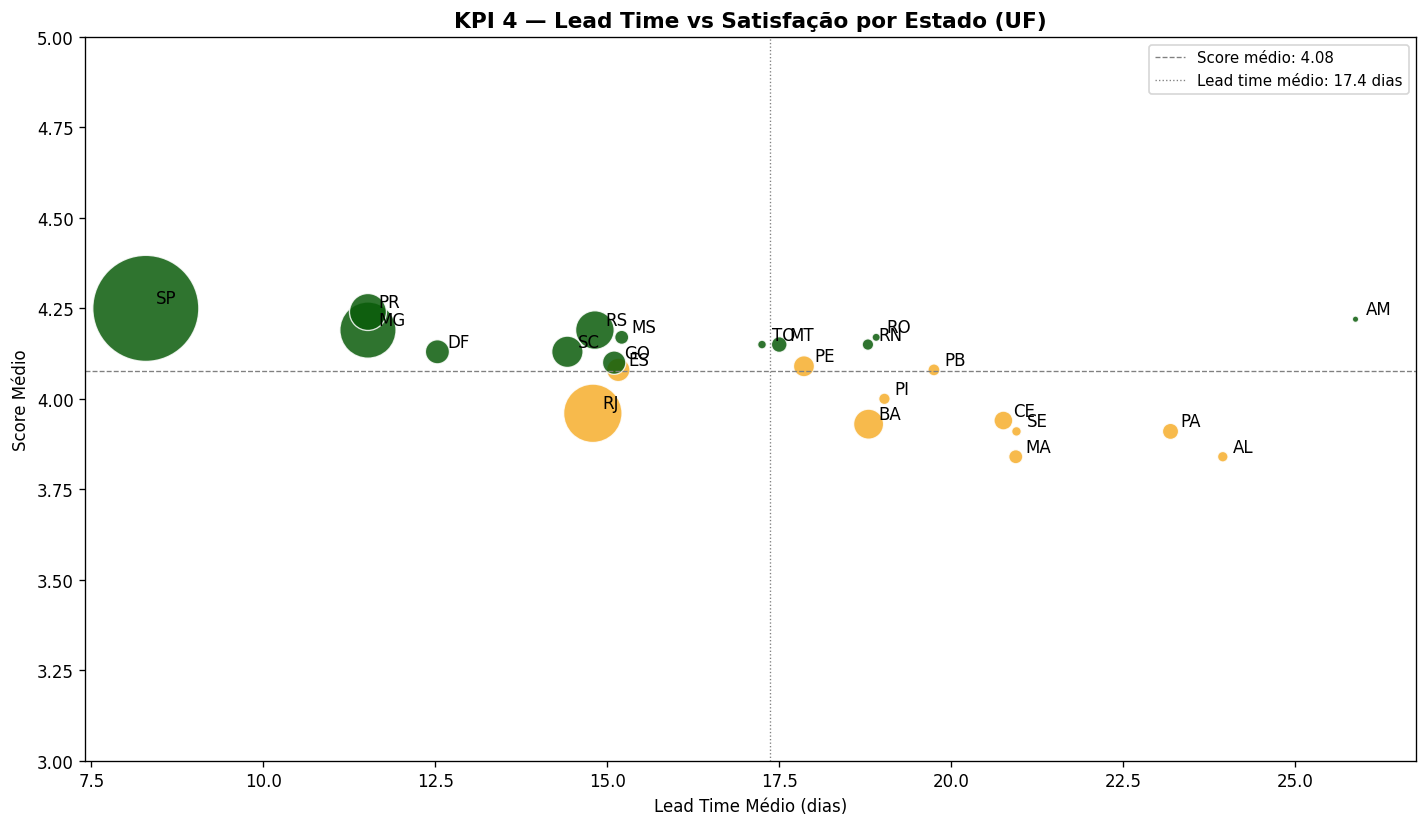

In [ ]:
# KPI 4 — Lead Time Médio vs Score Médio por UF
score_uf = (df_delivered.groupby('customer_state')
            .agg(score_medio=('review_score','mean'),
                 lead_medio=('lead_time_days','mean'),
                 volume=('review_score','count'))
            .query('volume >= 100')
            .round(2))

cores_uf = [COLOR_BAD if v < 3.8 else (COLOR_WARN if v < 4.1 else COLOR_OK)
            for v in score_uf['score_medio']]

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    score_uf['lead_medio'],
    score_uf['score_medio'],
    s=score_uf['volume'] / 10,
    c=cores_uf,
    edgecolors='white', linewidth=0.8, alpha=0.85
)

for uf, row in score_uf.iterrows():
    ax.annotate(uf, (row['lead_medio'], row['score_medio']),
                textcoords='offset points', xytext=(6, 3), fontsize=10)

ax.axhline(score_uf['score_medio'].mean(), color='gray', linestyle='--', linewidth=0.8,
           label=f'Score médio: {score_uf["score_medio"].mean():.2f}')
ax.axvline(score_uf['lead_medio'].mean(), color='gray', linestyle=':', linewidth=0.8,
           label=f'Lead time médio: {score_uf["lead_medio"].mean():.1f} dias')

ax.set_title('KPI 4 — Lead Time vs Satisfação por Estado (UF)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lead Time Médio (dias)')
ax.set_ylabel('Score Médio')
ax.set_ylim(3, 5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Análise Preditiva
> Modelo para identificar risco de insatisfação (churn risk)

In [ ]:
# Escolhendo atributos operacionais (removendo estado)
df_model = df_delivered[['lead_time_days', 'delay_days', 'price', 'freight_value',
                          'installments', 'payment_type', 'review_score']].dropna().copy()

# Target: insatisfeito = scoremenor q 3
df_model['insatisfeito'] = (df_model['review_score'] < 3).astype(int)

# Encoding apenas para forma de pagamento
le_pay = LabelEncoder()
df_model['payment_enc'] = le_pay.fit_transform(df_model['payment_type'])

# Lista de features atualizada sem estado
features = ['lead_time_days', 'delay_days', 'price', 'freight_value', 'installments', 'payment_enc']
X = df_model[features]
y = df_model['insatisfeito']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

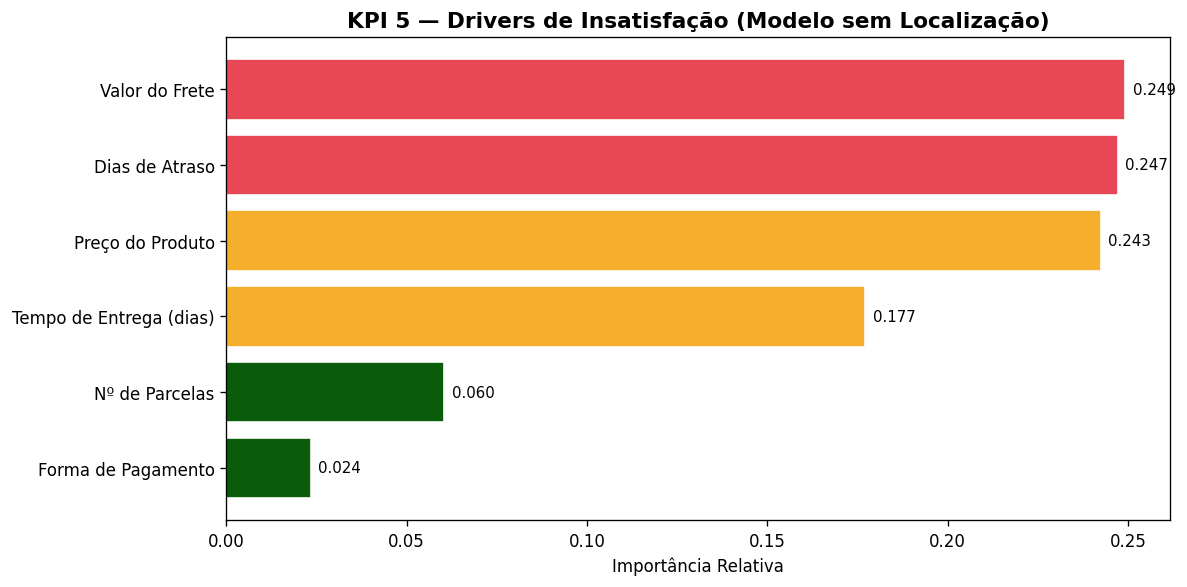

In [ ]:
# Importância das variáveis atualizada
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
labels_pt = {
    'lead_time_days': 'Tempo de Entrega (dias)',
    'delay_days':     'Dias de Atraso',
    'price':          'Preço do Produto',
    'freight_value':  'Valor do Frete',
    'installments':   'Nº de Parcelas',
    'payment_enc':    'Forma de Pagamento'
}
importances.index = [labels_pt[i] for i in importances.index]

cores_imp = [COLOR_BAD if v > importances.quantile(0.66)
             else (COLOR_WARN if v > importances.quantile(0.33) else COLOR_OK)
             for v in importances.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importances.index, importances.values, color=cores_imp, edgecolor='white')
ax.set_title('KPI 5 — Drivers de Insatisfação (Modelo sem Localização)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância Relativa')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Sumário Executivo

| KPI | Métrica | Interpretação |
|-----|---------|---------------|
| 1 | Distribuição de Score | Maioria (score 5) vs % crítica (1-2) |
| 2 | Lead Time por Score | Quanto maior o atraso, menor o score |
| 3 | Impacto do Atraso | Pedidos atrasados têm score menor |
| 4 | Lead Time e satisfação por UF | Impacto do atraso na satisfação do UF |
| 5 | Modelo Preditivo | Principais drivers de insatisfação |

### Recomendações
1. **Reduzir lead time** nas UFs com score crítico — impacto direto no score
2. **Monitorar % de atrasos** como KPI operacional semanal
3. **Priorizar ações** nos estados de maior volume + menor score
4. **Usar modelo preditivo** para alertar pedidos com alto risco de insatisfação antes da entrega
